## Carga y preparación de datos

En este bloque se carga el archivo CSV, se revisa su estructura, se convierten las fechas al tipo `datetime`, se verifican duplicados y valores nulos, y se crean las columnas `is_5xx` e `is_bad` para identificar eventos problemáticos.

In [ ]:
import pandas as pd

# Cargamos el csv
df = pd.read_csv ("server_logs.csv")

# Miramos la cantidad de filas y cantidad de columnas
filas, columnas = df.shape
print (f"Filas totales: {filas} \nColumnas totales: {columnas}")

# Miramos los nombres de las columnas
# print (df.columns.tolist())

# Analizamos los tipos de datos que almacena cada columna 
# print(df.dtypes)

# Analizar los servicios totales 
servicios = df['service_name'].value_counts ()
print (F"\n{servicios}")

# Converimos el timestamp_event y received_at que antes era str a datetime 
df["timestamp_event"] = pd.to_datetime (df['timestamp_event'], errors= 'coerce', utc=True)
df["received_at"] = pd.to_datetime (df["received_at"], errors='coerce', utc=True)

# Verificamos si hay nulos en la tabla
nulos= df.isna().sum()
# print (f"\nNulos:\n{nulos}")

# Verificar los datos de severity
datos = df['severity'].value_counts (dropna=False)
print (f"\n{datos}")

# Creamos las columnas is_5xx y is_bad
df['is_5xx'] = df ["status_code"].ge (500)
df["is_bad"] = df ["severity"].isin (["ERROR", "CRITICAL"]) | df["is_5xx"]

Filas totales: 5795 
Columnas totales: 15

service_name
api-gateway             1509
orders-service          1057
inventory-service        964
payment-service          842
auth-service             778
notification-service     645
Name: count, dtype: int64

severity
INFO        3542
WARN        1358
ERROR        775
CRITICAL     120
Name: count, dtype: int64


## Exploración inicial

En este bloque se realizan las consultas principales del dataset: cantidad total de logs, severidad más frecuente, servicios con mayor y menor cantidad de registros, mensaje más repetido y mensaje malo más frecuente. Es para tener una idea general sobre las informaciones extraidas del dataframe.


In [166]:
# Total de logs 
print (f"Total de Logs: {filas}")

# Severidad mas frecuente
severity = df['severity'].value_counts ()
most_severity = severity.index[0]
count_severity = severity.iloc[0]
print (f"\nLa severidad que mas se repitio es '{most_severity}' -> {count_severity} repeticiones")

# Servicio que genera mayor y menor Logs 
service = df['service_name'].value_counts ()

most_service = service.index [0]
count_max_service = service.iloc [0]

min_service = service.idxmin()
count_min_service = service.min()

print(f'''\nEl servicio con mayor Logs: {most_service} -> {count_max_service}
El servicio con menor Logs: {min_service} -> {count_min_service}''')

# El mensaje mas repetido y el mensaje "malo" mas repetido 
message = df['message'].value_counts()

most_repeat_message = message.index[0]
count_repeat_message = message.iloc[0]

bad_message = df.loc[df['is_bad'], 'message'].value_counts()
most_bad_message = bad_message.index[0]
count_bad_message = bad_message.iloc[0]

print (f"""
El mensaje mas repetido: 
{most_repeat_message} -> {count_repeat_message}

EL mensaje 'MALO' mas repetido: 
{most_bad_message} -> {count_bad_message}""")


Total de Logs: 5795

La severidad que mas se repitio es 'INFO' -> 3542 repeticiones

El servicio con mayor Logs: api-gateway -> 1509
El servicio con menor Logs: notification-service -> 645

El mensaje mas repetido: 
Health check OK -> 1196

EL mensaje 'MALO' mas repetido: 
Order creation failed - inventory lock timeout -> 197


## Detección del momento crítico

En este bloque se agrupan los logs en ventanas de cinco minutos utilizando `timestamp_event`.

Para cada ventana se calcula:

- La cantidad total de eventos.
- La cantidad de eventos malos.
- El porcentaje de eventos malos (`bad_rate`).

Luego se consideran únicamente las ventanas con al menos 20 eventos, se ordenan de mayor a menor según su `bad_rate` y se muestran las cinco peores.

La primera ventana del ranking se selecciona como el momento crítico del sistema, identificando su hora de inicio y su hora de finalización.

In [179]:
# Creamos una columna que agrupa mediante el tiempo 
df["window_start"] = df["timestamp_event"].dt.floor ("5min")


# Agrupamos por ventana de 5 min en un nuevo dataframe
window_summary = (
    df.groupby ("window_start").agg(
        total_events = ("is_bad", "size"),
        bad_events = ("is_bad", "sum")
    ).reset_index ()
)

# Calculamos el bad rate de las ventanas 
window_summary ["bad_rate"] = ((window_summary["bad_events"] / window_summary ["total_events"])*100).round(2)

#Creamos un nuevo dataframe que contiene solo las filas ventanas validas
eligible = window_summary[ window_summary ["total_events"] >= 20 ].copy ()

if eligible.empty:
    raise ValueError ("No hay ninguna ventana con al menos 20 eventos")

# Ordenamos el dataframe 
eligible = eligible.sort_values (
    by= ["bad_rate", "bad_events", "total_events"],
    ascending= [False, False, False]
)

# Sacamos los peores 5 momentos 
top5 = eligible.head (5)
print (top5)

# Vemos en que momento ocurrio el momento critico 
critical_start = top5.iloc[0]['window_start']
print (f'\n{critical_start}')

critical_end = critical_start + pd.Timedelta (minutes=5)

print (f"\nMomento critico: {critical_start} -> {critical_end}")


                 window_start  total_events  bad_events  bad_rate
134 2026-01-10 11:10:00+00:00           189         110     58.20
135 2026-01-10 11:15:00+00:00           228         129     56.58
136 2026-01-10 11:20:00+00:00           111          59     53.15
462 2026-01-11 14:35:00+00:00           255         117     45.88
461 2026-01-11 14:30:00+00:00           156          68     43.59

2026-01-10 11:10:00+00:00

Momento critico: 2026-01-10 11:10:00+00:00 -> 2026-01-10 11:15:00+00:00


### Criterio para identificar el endpoint más comprometido

Se utiliza como criterio la cantidad de eventos malos registrados por endpoint durante el momento crítico. Un evento se considera malo cuando su severidad es `ERROR` o `CRITICAL`, o cuando presenta un `status_code` mayor o igual que 500.

In [ ]:
# Separamos el momento critico y el baseline
incidente = df[df['window_start'] == critical_start].copy ()
baseline = df[df['window_start'] != critical_start].copy ()

# Separamos solo los eventos malos dentro de la ventana critica 
incident_bad = incidente[incidente["is_bad"]].copy ()

service_ranking = incident_bad['service_name'].value_counts ()
print (f"Los servicios malos mas repetido: \n{service_ranking.head (3)}")

# Vemos los mensajes malos mas repetidos dentro de la ventana critica
top_message = incident_bad['message'].value_counts()
print (f"\nLos mensaje malos mas repetido: \n{top_message.head(3)}")

# Los endpoint mas comprometidos
top_endpoint = incident_bad['endpoint'].value_counts ().head (5)
print (f"\nLos endpoint con mas fallas: \n{top_endpoint.head()}")

cruce = incident_bad.groupby(['service_name', 'endpoint']).size().sort_values (ascending = False)
# print (f"\n{cruce.head(3)}")

#porcentaje de errores de orders-servie dentro del los malos eventos 
bad_total_event = incident_bad["is_bad"].sum ()
bad_orders_ratio = (service_ranking.max () / bad_total_event)*100
print (f"\nEl porcentaje de errores dentro de la ventana critica de {service_ranking.idxmax()} es de {bad_orders_ratio:.2f}")

Los servicios malos mas repetido: 
service_name
orders-service       72
inventory-service    37
payment-service       1
Name: count, dtype: int64

Los mensaje malos mas repetido: 
message
Order creation failed - inventory lock timeout    72
Database deadlock detected                        37
External dependency error                          1
Name: count, dtype: int64

Los endpoint con mas fallas: 
endpoint
/orders/cancel    26
/orders/create    25
/orders/status    21
/inv/reserve      18
/inv/stock        13
Name: count, dtype: int64

El porcentaje de errores dentro de la ventana critica de orders-service es de 65.45


## Comparación del incidente con el baseline

En este bloque se crea una función que resume un grupo de logs calculando la cantidad total de eventos, el `bad_rate`, la latencia promedio y el porcentaje de errores `5xx`.

Luego, la función se aplica tanto a la ventana crítica como al baseline para construir una tabla comparativa y observar qué cambió durante el incidente respecto al resto del dataset.

In [150]:
# Funcion que nos ayudara a parametrizar datos 
def resumen_grupo (grupo):
    total = len (grupo)
    bad = grupo["is_bad"].sum ()
    bad_rate = (bad/total)*100
    avg_latency = grupo["latency_ms"].mean ()
    pct_5xx = (grupo["is_5xx"].sum() / total )*100

    return pd.Series ({
        "total_events": total,
        "bad_rate": round(bad_rate, 2),
        "avg_latency_ms": round (avg_latency, 2),
        "%_5xx": round(pct_5xx, 2)
    
    })

# Nos ayuda a comprar los valores del Ventana Critica vs Baseline
tabla_comparativa = pd.DataFrame ({
    "Incidente": resumen_grupo (incidente),
    "Baseline": resumen_grupo (baseline)
})

tabla_comparativa

,Incidente,Baseline
total_events,189.00,5606.00
bad_rate,58.20,14.00
avg_latency_ms,1589.69,521.09
%_5xx,58.20,14.00


## Gráfico temporal por severidad

En este bloque se agrupan los eventos por ventana de cinco minutos y por nivel de severidad.

Luego se genera un gráfico de líneas que muestra cómo varía la cantidad de eventos `INFO`, `WARN`, `ERROR` y `CRITICAL` a lo largo del tiempo. Esto permite identificar visualmente en qué momentos aumentan los errores y si existe una concentración de eventos problemáticos durante la ventana crítica.

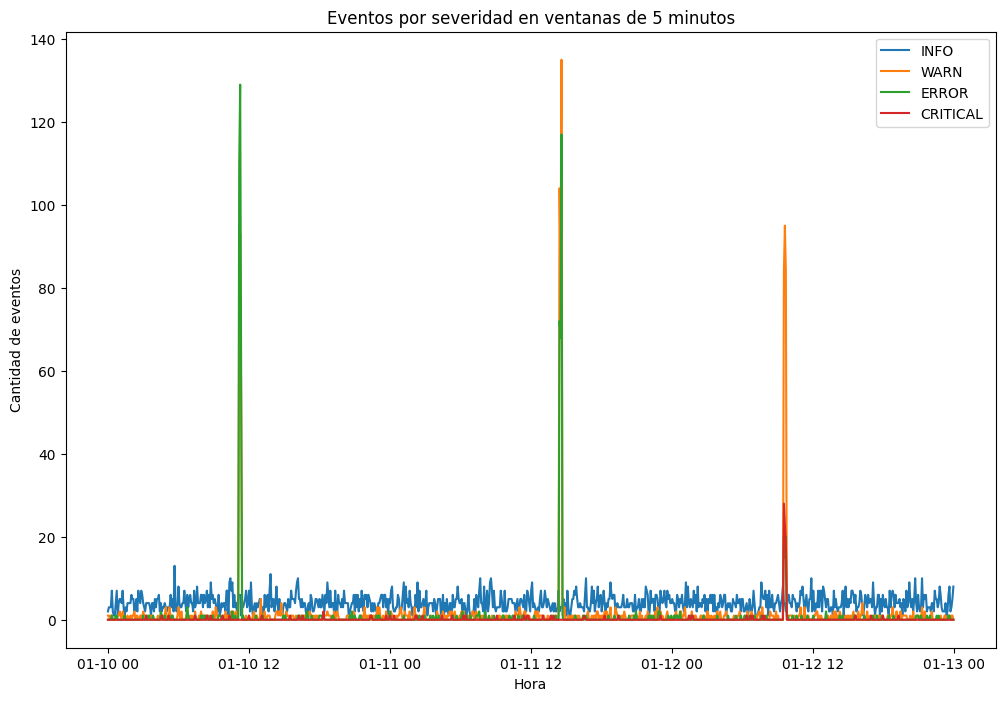

In [ ]:
import matplotlib.pyplot as plt

# Grafico por severidad
severidad_por_ventana = (
    df.groupby(["window_start", "severity"]).size().unstack (fill_value=0)
)

# Creamos donde estaremos graficando
fig, ax = plt.subplots (figsize = (12, 8))

# iteramos para que se vayan graficando de acuerdo a la lista 
for severidad in ["INFO", "WARN", "ERROR", "CRITICAL"]:
    ax.plot (severidad_por_ventana.index, severidad_por_ventana [severidad], label = severidad)

# Agregamos los titulos
ax.set_title ("Eventos por severidad en ventanas de 5 minutos")
ax.set_xlabel ("Hora")
ax.set_ylabel ("Cantidad de eventos")
ax.legend ()
plt.show ()


## Evolución temporal del bad rate

En este bloque se grafica el porcentaje de eventos malos en cada ventana de cinco minutos.

La zona sombreada identifica el momento crítico, lo que permite visualizar cómo aumentó el `bad_rate` durante el incidente en comparación con las demás ventanas del dataset.

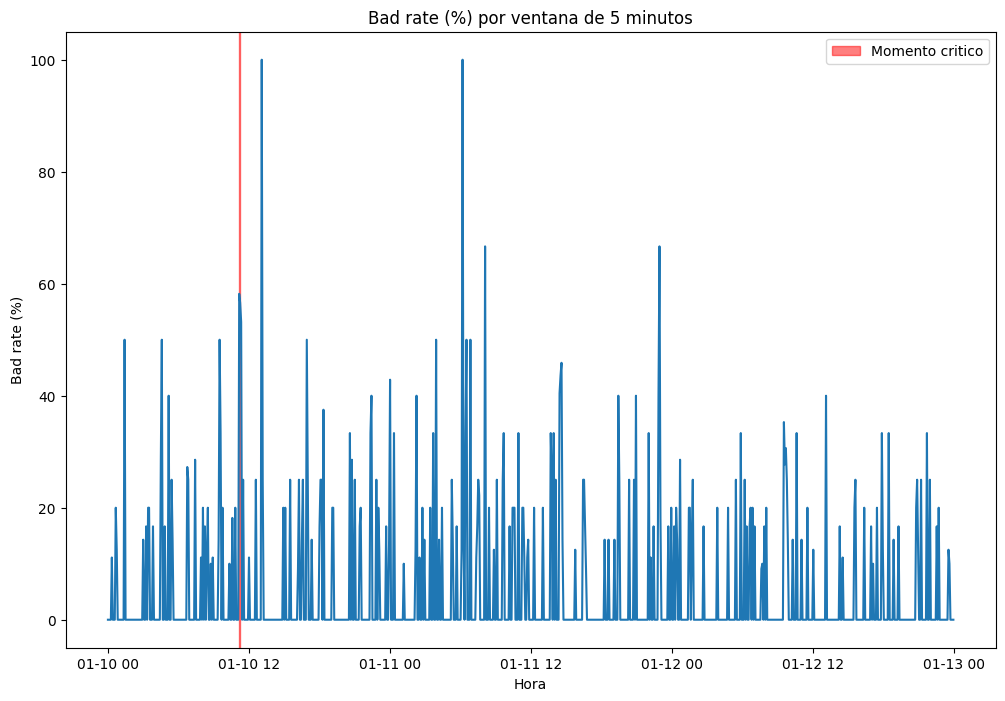

In [ ]:
fig, ax = plt.subplots (figsize = (12, 8))

ax.plot (window_summary ["window_start"], window_summary["bad_rate"])

# Cremos la linea vertical donde ocurrio el momento critico 
ax.axvspan (critical_start, critical_end, alpha = 0.5, color = "red", label = "Momento critico")

ax.set_title ("Bad rate (%) por ventana de 5 minutos")
ax.set_xlabel ("Hora")
ax.set_ylabel ("Bad rate (%)")
ax.legend ()
plt.show ()





## Conclusiones del análisis

En este bloque se recuperan los resultados principales del análisis: momento crítico, servicio más afectado, endpoint más comprometido, mensaje dominante y diferencia del `bad_rate` entre el incidente y el baseline.

Finalmente, se genera una conclusión automática utilizando los valores calculados previamente, garantizando que el resultado sea reproducible.

In [ ]:
critical_service = incident_bad ['service_name'].value_counts ().idxmax ()
critical_endpoint = incident_bad ['endpoint'].value_counts ().idxmax ()
dominant_message = incident_bad ['message'].value_counts ().idxmax ()

bad_latency = tabla_comparativa.loc["avg_latency_ms", "Incidente"]
baseline_latency = tabla_comparativa.loc["avg_latency_ms", "Baseline"]


incident_bad_rate = tabla_comparativa.loc ['bad_rate', 'Incidente']
baseline_bad_rate = tabla_comparativa.loc ['bad_rate', 'Baseline']


conclusion = f"""
El momento critico del sistema se detecto entre {critical_start} y {critical_end},
con un bad_rate de {incident_bad_rate}%, frente a un {baseline_bad_rate}% en el baseline, lo que
representa un incremento considerable en la proporcion de eventos malos.

El servicio que mas fue afectado fue {critical_service}, concentrando la mayoria de los eventos
malos de esta ventana es del {bad_orders_ratio:.2f}% de un total de {bad_total_event}. El endpoint mas comprometido,
segun la cantidad de eventos malos, fue "{critical_endpoint}". EL mensjae mas dominante durante la ventana critica 
fue "{dominant_message}". La comparacion entre la ventana crtitica vs el Baseline nos muestra que el sistenma opero 
con una tasa de errores mucho mas alta durante ese periodo, concentrado principalmente en el flujo de creacion 
y cancelacion de ordenes.

Tambien podemos deducir o tener una hipotesis de lo que desencadeno pudo ser el que el servidor haya 
recibido una sobrecarga de solicitud, generando una saturacion lo cual desencadeno que el bloque de 
inventario tardaran mas de lo habitual y excedieran su tiempo limite de espera, tambien hizo que la 
latencia sea mucho mayor en esa ventana {bad_latency}ms con respecto al valor de {baseline_latency}ms del Baseline.

"""

print (conclusion)


El momento critico del sistema se detecto entre 2026-01-10 11:10:00+00:00 y 2026-01-10 11:15:00+00:00,
con un bad_rate de 58.2%, frente a un 14.0% en el baseline, lo que
representa un incremento considerable en la proporcion de eventos malos.

El servicio que mas fue afectado fue orders-service, concentrando la mayoria de los eventos
malos de esta ventana es del 65.45% de un total de 110. El endpoint mas comprometido, segun la cantidad de eventos malos, fue 
"/orders/cancel". EL mensjae mas dominante durante la ventana critica fue "Order creation failed - inventory lock timeout".
La comparacion entre la ventana crtitica vs el Baseline nos muestra que el sistenma opero 
con una tasa de errores mucho mas alta durante ese periodo, concentrado principalmente en el flujo
de creacion y cancelacion de ordenes.

Tambien podemos deducir o tener una hipotesis de lo que desencadeno pudo ser el que el servidor haya 
recibido una sobrecarga de solicitud, generando una saturacion lo cual desencaden